# Model Training

## Notebook Setup

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## Setup Paths

In [21]:
project_root = Path(os.getcwd()).parent
RAW_DATA_ROOT = project_root / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
CONFIG_PATH = project_root / "config" / "feature_map.yaml"

# Ensure the processed directory exists
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load Processed Data

In [22]:
df = pd.read_parquet(PROCESSED_DATA_DIR / 'master_dataset.parquet')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5242948 entries, 0 to 5242947
Data columns (total 20 columns):
 #   Column              Dtype         
---  ------              -----         
 0   time_stamp          datetime64[ns]
 1   farm_id             object        
 2   asset_id            object        
 3   amb_temp            float64       
 4   wind_speed          float64       
 5   pitch_angle         float64       
 6   active_power        float64       
 7   gen_speed           float64       
 8   gearbox_oil_temp    float64       
 9   transformer_temp    float64       
 10  nacelle_temp        float64       
 11  hub_temp            float64       
 12  yaw_error           float64       
 13  vibration_raw       float64       
 14  hydraulic_temp      float64       
 15  temp_delta_gearbox  float64       
 16  power_efficiency    float64       
 17  temp_rolling_mean   float64       
 18  temp_divergence     float64       
 19  target              int64         
dtypes:

,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,temp_delta_gearbox,power_efficiency,temp_rolling_mean,temp_divergence,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,19.0,-0.521067,41.0,0.0,0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,19.0,-0.520252,41.0,0.0,0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,19.0,-3.720165,41.0,0.0,0
3,2022-08-04 06:40:00,A,0,22.0,1.5,24.0,-2.548,0.4,41.0,66.000000,29.0,30.0,-49.1,1.9,41.0,19.0,-0.754963,41.0,0.0,0
4,2022-08-04 06:50:00,A,0,22.0,1.0,24.0,-2.568,0.0,41.0,65.666667,29.0,30.0,-107.3,0.0,41.0,19.0,-2.568000,41.0,0.0,0


In [23]:
# Initialize splitter with stratification by farm_id
splitter = WindFarmSplitter(random_state=42)

# This will give us a 20% test set of unique turbines
train_df, test_df = splitter.get_train_test_split(df, test_size=0.2)

# Prepare Features and Target
# We exclude ID columns and the target itself
features = [
    'active_power', 'wind_speed', 'gen_speed', 'amb_temp', 
    'gearbox_oil_temp', 'temp_delta_gearbox', 'power_efficiency', 
    'temp_divergence'
]

X_train, y_train = train_df[features], train_df['target']
X_test, y_test = test_df[features], test_df['target']

print(f"Training Samples: {len(X_train):,}")
print(f"Testing Samples:  {len(X_test):,}")

Training Samples: 4,681,113
Testing Samples:  1,677,783


In [ ]:
model_types = ['xgboost', 'rf', 'logistic']
results_list = []

for m_type in model_types:
    print(f"\n--- Training {m_type.upper()} ---")
    
    # Initialize trainer
    trainer = WindFailureTrainer(model_type=m_type)
    
    # The .train() method in your trainer.py now handles 
    # the 1:46 imbalance automatically via scale_pos_weight
    trainer.train(X_train, y_train)
    
    # Evaluate on unseen turbines
    metrics = trainer.evaluate(X_test, y_test)
    metrics['model'] = m_type
    results_list.append(metrics)

# Display Results
results_df = pd.DataFrame(results_list).set_index('model')
print("\nFinal Results on Unseen Turbines:")
print(results_df[['accuracy', 'precision', 'recall', 'f1', 'auc']])


--- Training XGBOOST ---

--- Training RF ---


In [ ]:
# Focus on the best performing model (likely XGBoost)
best_model = trainer.model # Assuming XGBoost was last in loop

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly']).plot(ax=ax, cmap='Blues')
plt.title("XGBoost Performance on Unseen Turbines")
plt.show()

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title("Key Predictors of Turbine Failure")
plt.ylabel("Importance Score")
plt.show()

In [7]:
print(f'Option C ~ {7487.33 / 150:.2f} / lft')
print(f'Option A ~ {10279.43 / 232:.2f} / lft')
print(f'Option B ~ {14263.28 / 349:.2f} / lft')

Option C ~ 49.92 / lft
Option A ~ 44.31 / lft
Option B ~ 40.87 / lft


In [3]:
# Load the feature data
config_path = '../config/feature_map.yaml'
processor = WindFarmProcessor(config_path=config_path)

processed_path = '../data/processed'
df = processor.load_processed_dataset(processed_dir=processed_path)

Combining 95 turbines into master dataset...
Dropping 10 constant indicators: ['has_amb_temp', 'has_wind_speed', 'has_pitch_angle', 'has_active_power', 'has_gen_speed', 'has_gearbox_oil_temp', 'has_transformer_temp', 'has_nacelle_temp', 'has_hub_temp', 'has_vibration_raw']


In [4]:
df.isna().any()

time_stamp                  False
asset_id                    False
farm_id                     False
amb_temp                    False
wind_speed                  False
pitch_angle                 False
active_power                False
gen_speed                   False
gearbox_oil_temp            False
transformer_temp            False
nacelle_temp                False
hub_temp                    False
yaw_error                   False
has_yaw_error               False
vibration_raw               False
hydraulic_temp              False
has_hydraulic_temp          False
temp_delta_gearbox          False
power_efficiency            False
vibration_magnitude         False
yaw_stress_index            False
temp_divergence             False
temp_trend_24h              False
rpm_volatility_6h           False
rpm_volatility_24h          False
yaw_stress_persistent_6h    False
target                      False
dtype: bool

In [5]:
df.head()

,time_stamp,asset_id,farm_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,has_yaw_error,vibration_raw,hydraulic_temp,has_hydraulic_temp,temp_delta_gearbox,power_efficiency,vibration_magnitude,yaw_stress_index,temp_divergence,temp_trend_24h,rpm_volatility_6h,rpm_volatility_24h,yaw_stress_persistent_6h,target
0,2022-01-02 00:00:00,0,A,18.0,7.4,-2.2,249.872,1546.6,52.0,77.666667,26.0,26.0,-2.4,1,67.5,31.0,1,34.0,0.616627,0.0,2.4,3.895833,7.0,74.976134,439.325680,9.733333,0
1,2022-01-02 00:10:00,0,A,18.0,7.8,-2.2,296.300,1586.6,52.0,77.666667,26.0,26.0,5.6,1,36.6,31.0,1,34.0,0.624378,0.0,5.6,3.847222,7.0,83.811492,440.818420,9.786111,0
2,2022-01-02 00:20:00,0,A,18.0,7.4,-2.1,257.142,1542.7,53.0,78.333333,26.0,26.0,-12.4,1,91.9,31.0,1,35.0,0.634568,0.0,12.4,4.791667,8.0,88.874771,442.001698,10.036111,0
3,2022-01-02 00:30:00,0,A,18.0,7.7,-2.2,278.200,1570.4,53.0,78.666667,26.0,27.0,0.6,1,68.0,31.0,1,35.0,0.609375,0.0,0.6,4.736111,8.0,94.550939,443.337350,9.591667,0
4,2022-01-02 00:40:00,0,A,18.0,7.9,-2.2,297.018,1579.7,54.0,78.666667,26.0,27.0,-17.3,1,53.4,31.0,1,36.0,0.602423,0.0,17.3,5.680556,8.0,99.617640,444.664227,9.952778,0


In [6]:
df.drop(columns=['vibration_magnitude'], inplace=True)
df.head()

,time_stamp,asset_id,farm_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,has_yaw_error,vibration_raw,hydraulic_temp,has_hydraulic_temp,temp_delta_gearbox,power_efficiency,yaw_stress_index,temp_divergence,temp_trend_24h,rpm_volatility_6h,rpm_volatility_24h,yaw_stress_persistent_6h,target
0,2022-01-02 00:00:00,0,A,18.0,7.4,-2.2,249.872,1546.6,52.0,77.666667,26.0,26.0,-2.4,1,67.5,31.0,1,34.0,0.616627,2.4,3.895833,7.0,74.976134,439.325680,9.733333,0
1,2022-01-02 00:10:00,0,A,18.0,7.8,-2.2,296.300,1586.6,52.0,77.666667,26.0,26.0,5.6,1,36.6,31.0,1,34.0,0.624378,5.6,3.847222,7.0,83.811492,440.818420,9.786111,0
2,2022-01-02 00:20:00,0,A,18.0,7.4,-2.1,257.142,1542.7,53.0,78.333333,26.0,26.0,-12.4,1,91.9,31.0,1,35.0,0.634568,12.4,4.791667,8.0,88.874771,442.001698,10.036111,0
3,2022-01-02 00:30:00,0,A,18.0,7.7,-2.2,278.200,1570.4,53.0,78.666667,26.0,27.0,0.6,1,68.0,31.0,1,35.0,0.609375,0.6,4.736111,8.0,94.550939,443.337350,9.591667,0
4,2022-01-02 00:40:00,0,A,18.0,7.9,-2.2,297.018,1579.7,54.0,78.666667,26.0,27.0,-17.3,1,53.4,31.0,1,36.0,0.602423,17.3,5.680556,8.0,99.617640,444.664227,9.952778,0


## Split Data

In [7]:
# Split by Turbine ID (20% held out for final test)
splitter = WindFarmSplitter(n_splits=5)
train_df, test_df = splitter.get_train_test_split(df, test_size=0.2)

Split Summary:
  Train: 28 turbines (4562823 rows)
  Test:  8 turbines (1377498 rows)


## Prepare Data (i.e., drop columns, apply scaling, etc.)

In [8]:
# Prepare X and y (Scaling is handled inside prepare_xy)
X_train, y_train = splitter.prepare_xy(train_df, fit_scaler=True)
X_test, y_test = splitter.prepare_xy(test_df, fit_scaler=False)

## Train Models

In [9]:
X_train.loc[X_train.isna().any(axis=1)]

,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,has_yaw_error,vibration_raw,hydraulic_temp,has_hydraulic_temp,temp_delta_gearbox,power_efficiency,yaw_stress_index,temp_divergence,temp_trend_24h,rpm_volatility_6h,rpm_volatility_24h,yaw_stress_persistent_6h


In [10]:
X_test.isna().any()

amb_temp                    False
wind_speed                  False
pitch_angle                 False
active_power                False
gen_speed                   False
gearbox_oil_temp            False
transformer_temp            False
nacelle_temp                False
hub_temp                    False
yaw_error                   False
has_yaw_error               False
vibration_raw               False
hydraulic_temp              False
has_hydraulic_temp          False
temp_delta_gearbox          False
power_efficiency            False
yaw_stress_index            False
temp_divergence             False
temp_trend_24h              False
rpm_volatility_6h           False
rpm_volatility_24h          False
yaw_stress_persistent_6h    False
dtype: bool


--- Starting Model Comparison ---
Training logistic...
Training rf...


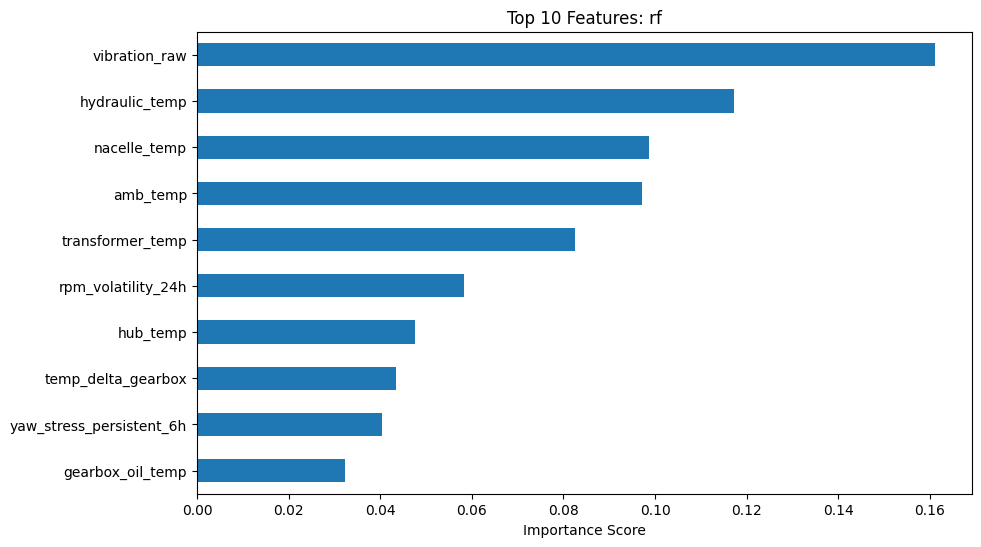

Training xgboost...


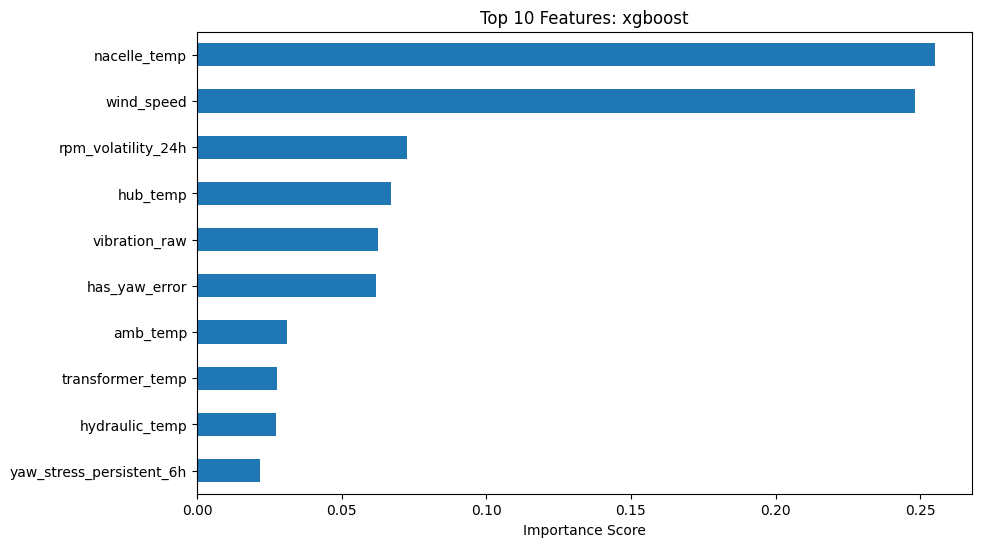

In [11]:
# Compare Models
model_types = ['logistic', 'rf', 'xgboost']
results_list = []

print("\n--- Starting Model Comparison ---")

for m_type in model_types:
    print(f"Training {m_type}...")
    
    # Initialize and Train
    trainer = WindFailureTrainer(model_type=m_type)
    trainer.train(X_train, y_train)

    # Get feature importance
    if m_type in ['xgboost', 'rf']:
        importance = trainer.model.feature_importances_
        feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
        # Plot top 10
        plt.figure(figsize=(10, 6))
        feat_imp.head(10).plot(kind='barh').invert_yaxis()
        plt.title(f"Top 10 Features: {m_type}")
        plt.xlabel("Importance Score")
        plt.show()
        
    # Evaluate on the unseen test turbines
    metrics = trainer.evaluate(X_test, y_test)
    results_list.append(metrics)    

## Compare Models

In [13]:
# Display Comparison Table
results_df = pd.DataFrame(results_list).set_index('model')
print("\nFinal Results on Unseen Turbines:")
print(results_df.sort_values(by='f1', ascending=False))


Final Results on Unseen Turbines:
          precision    recall        f1       auc
model                                            
rf         0.355209  1.000000  0.524213  0.999741
xgboost    0.459459  0.039261  0.072340  0.999673
logistic   0.000934  0.692841  0.001866  0.814689
